# Анализ влияния экранного времени и сна на успеваемость и психологическое состояние студентов.

### Ключевые задачи проекта:
- Есть ли закономерность между количеством сна и стрессом?
- Есть ли закономерность между величиной экранного времени и количеством сна?
- Есть ли закономерность между величиной экранного времени и успеваемостью?
-



In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df=pd.read_csv('student_sleep_mental_health_2026.csv')

In [52]:
print("=== Описательная статистика ===")
print(df[['avg_sleep_hours', 'screen_time_hours', 'stress_level', 'gpa']].describe().drop('count'))

=== Описательная статистика ===
      avg_sleep_hours  screen_time_hours  stress_level       gpa  \
mean         7.414067           6.494667      7.216667  3.244487   
std          0.971279           2.165014      1.572433  0.379404   
min          4.400000           1.000000      1.000000  1.970000   
25%          6.800000           5.000000      6.000000  2.980000   
50%          7.400000           6.500000      7.000000  3.245000   
75%          8.100000           8.000000      8.000000  3.510000   
max         10.900000          13.600000     10.000000  4.000000   

      anxiety_score  
mean       7.152000  
std        1.994882  
min        1.000000  
25%        6.000000  
50%        7.000000  
75%        9.000000  
max       10.000000  


### Какие особенности можно заметить

**Сон:**
На основе значения разброса(std=0.97) можно сделать вывод, что большинство студентов спит от 6.8 до 8.1 часов в сутки.

**Экранное время:**
Среднее экранное время равно 6.5 часов, что при средних показателях продолжительности сна занимает около 40% часов бодрствования.

**Уровень стресса:**
Среднее значение стресса составляет 7.2 из 10. Это говорит о том, что среди студентов большой стресс-это распространенное явление.

**GPA:**
В среднем GPA равен 3.24 из 4, что соотносится с оценкой "хорошо" и является высоким показателем



### Есть ли закономерность между количеством сна и стрессом?

Корреляция между продолжительностью сна и уровнем стресса: -0.496


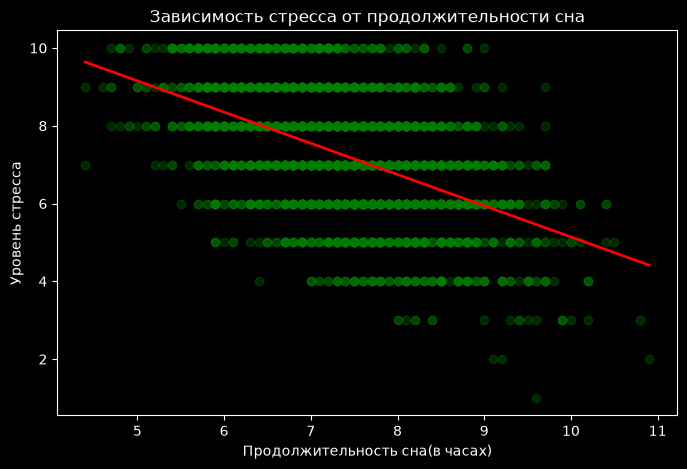

In [38]:
cor=df['avg_sleep_hours'].corr(df['stress_level'])
print(f"Корреляция между продолжительностью сна и уровнем стресса: {cor:.3f}")
plt.figure(figsize=(8,5))
plt.scatter(df['avg_sleep_hours'], df['stress_level'], alpha=0.3, color='green')
z=np.polyfit(df['avg_sleep_hours'], df['stress_level'], 1)
p=np.poly1d(z)
plt.plot(df['avg_sleep_hours'].sort_values(), p(df['avg_sleep_hours'].sort_values()),color='red', linewidth=2)
plt.xlabel('Продолжительность сна(в часах)')
plt.ylabel('Уровень стресса')
plt.title('Зависимость стресса от продолжительности сна')
plt.show()


**Вывод:**
Значение корреляии -0.496 говорит о наличии умеренной обратной связи между метриками. Получается, можно говорить о том, что студенты, которые спят больше, в среднем испытывают меньший стресс.

**Объяснение:**
1) Сон это важнейший процесс для регуляции гормонов. В том числе, сон непосредственно влияет на уровень кортизола, иначе-гормон стресса. Качественный и достаточный необходим для поддержания баланса кортизола. Однако недосып ведет к увеличению выработки кортизола и сдвигает пик выработки кортизола на вечернее время. В силу этого, выходит, что пик стресса приходится на примерно на то время, когда человек собирается ложиться спать, а стресс, как многим известно сопровождается тревожным состоянием и навязчивыми мыслями. Эти мысли мешают раслабиться и лечь спать. Итого, недосып повышает выработку кортизола и влечет к еще бОльшим осложнениям со сном в будущем.



### Есть ли закономерность между величиной экранного времени в соцсетях и количеством сна?

Корреляция между продолжительностью сна и уровнем стресса: -0.587


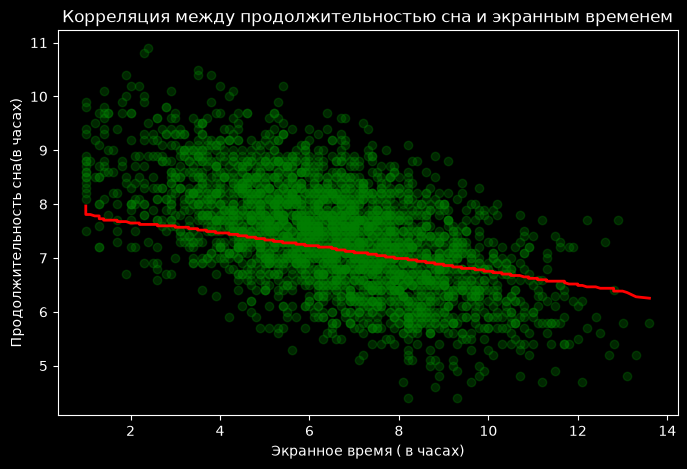

In [42]:
cor=df['screen_time_hours'].corr(df['avg_sleep_hours'])
print(f"Корреляция между продолжительностью сна и уровнем стресса: {cor:.3f}")
plt.figure(figsize=(8,5))
plt.scatter(df['screen_time_hours'], df['avg_sleep_hours'], alpha=0.3, color='green')
z=np.polyfit(df['screen_time_hours'], df['avg_sleep_hours'], 1)
p=np.poly1d(z)
plt.plot(df['screen_time_hours'].sort_values(), p(df['avg_sleep_hours'].sort_values()),color='red', linewidth=2)
plt.xlabel('Экранное время ( в часах)')
plt.ylabel('Продолжительность сна(в часах)')
plt.title('Корреляция между продолжительностью сна и экранным временем')
plt.show()

Заметим, что значение корреляции в -0.587 по модулю выше, чем 0.5, а значит это значимая обратная корреляция. То есть, в среднем, студенты, уделяющие электронным гаджетам больше времени имеют меньше продолжительность сна.

**Объяснение:**
1) Синий свет от экрана подавляет выработку мелатонина(гормон отвечающий за засыпание). Вследствие этого, человек позже засыпает, что сокращает продолжительность сна и ломает режим
2) Социальные сети создаются таким образом, чтобы пользователю хотелось провести как можно больше времени в ней. Современные соцсети отличаются быстрым контентом-короткие видео и фото. Такой формат контента создает удержание внимания зрителя путем постоянной смены кадров и эмоций. Пользователь фокусируется на контенте и забывает о том, сколько времени прошло из-за чего может заснуть гораздо позже



### Есть ли закономерность между величиной экранного времени в соцсетях и успеваемостью?

Корреляция между значением экранного времени и GPA: -0.469


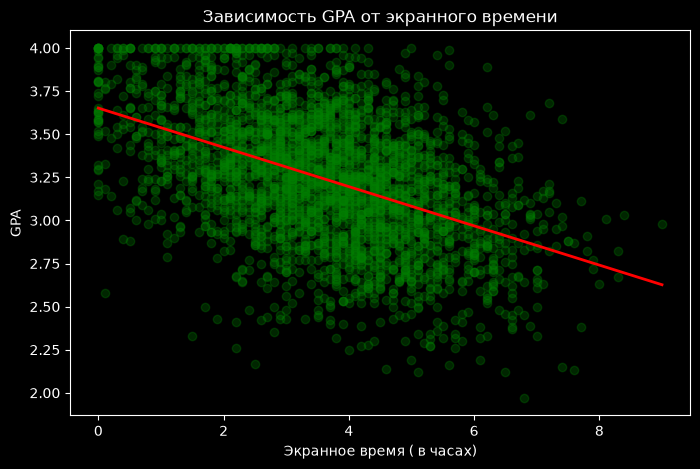

In [45]:
corr = df['social_media_hours'].corr(df['gpa'])
print(f"Корреляция между значением экранного времени и GPA: {corr:.3f}")
plt.figure(figsize=(8, 5))
plt.scatter(df['social_media_hours'], df['gpa'], alpha=0.3, color='green')
z=np.polyfit(df['social_media_hours'], df['gpa'], 1)
p=np.poly1d(z)
x_sorted=np.sort(df['social_media_hours'])
plt.plot(x_sorted, p(x_sorted), color='red', linewidth=2)
plt.xlabel('Экранное время ( в часах)')
plt.ylabel('GPA')
plt.title('Зависимость GPA от экранного времени')
plt.show()

**Вывод:**
Значение корреляции -0.469 говорит о наличии умеренной обратной связи между метриками. Соответственно, можно говорить о том, что студенты, показатель экранного времени которых меньше, в среднем имеют больший GPA.

**Объяснение:**
1) Чем больше человек проводит времени за экраном, тем меньше времени и сил у него остается на учебу. Многие полагают, что сидеть в интернете-это разновидность отдыха, но на самом деле исследования показывают, что мозг затрачивает на обработку цифрового контента практически столько же ресурсов, сколько и на интеллектуальную деятельность (чтение, решение задач, написание текстов).
2) Ряд исследований, проведенных на тему влияния экранного времени на прокрастинацию говорят о том, что большое экранное время способствует прокрастинации и прокрастинация способствует увеличению экранного времени. Прокрастинация может возникать из-за стресса, страха допустить ошибку, усталости, наличия слишком сложного или размытого задания и пр. Вместо того, чтобы начать, человек откладывает на неопределенное "потом", и начинает работать, когда времени остается катастрофически мало. Следствием этого может быть, низкое погружение в работу, большое количество ошибок, невыполнение в срок и другие маркеры, которые понижают оценку.

